# Studies about gravitational waves, glitches on O3 run data - We need be able to obtain data from LIGO, HANFORD and VIRGO interferometers, manipulate this data and plot the results from O3 run.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## We can search for data in three ways: i) ifo: **{H1, L1, V1}** from LIGO-DVweb site or ii) ifo: **{H1, L1}** from Zenodo website and iii) directly using libraries and functions in python.

## The first one as follow

In [80]:
dfligo_L1_O3a = pd.read_csv("L1_O3a_gspyLIGO.csv").drop_duplicates()
dfligo_H1_O3a = pd.read_csv("H1_O3a_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3a = pd.read_csv("V1_O3a_gspyLIGO.csv").drop_duplicates()

dfligo_L1_O3b = pd.read_csv("L1_O3b_gspyLIGO.csv").drop_duplicates()
dfligo_H1_O3b = pd.read_csv("H1_O3b_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3b = pd.read_csv("V1_O3b_gspyLIGO.csv").drop_duplicates()

In [81]:
dfzenodo_L1_O3a = pd.read_csv("L1_O3a_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3a = pd.read_csv("H1_O3a_Zenodo.csv.csv").drop_duplicates()

dfzenodo_L1_O3b = pd.read_csv("L1_O3b_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3b = pd.read_csv("H1_O3b_Zenodo.csv.csv").drop_duplicates()

In [83]:
dfzenodo_L1_O3a.rename(columns={'ml_label': 'label'}, inplace=True)
dfzenodo_L1_O3b.rename(columns={'ml_label': 'label'}, inplace=True)

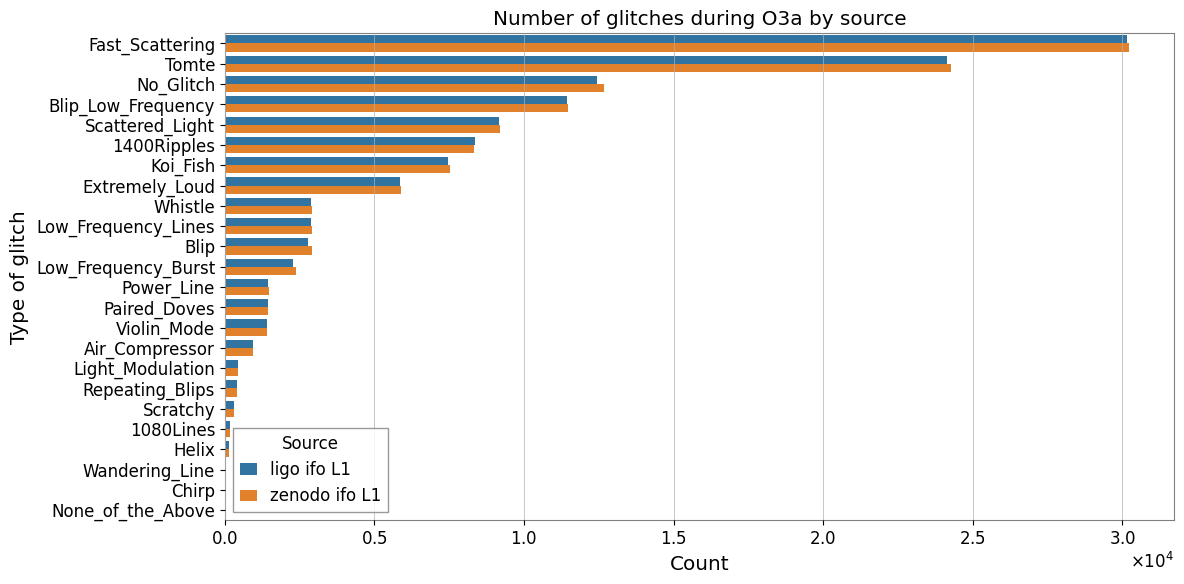

In [95]:
# Adiciona a origem
dfligo_L1_O3a['Fonte'] = 'ligo ifo L1'
dfzenodo_L1_O3a['Fonte'] = 'zenodo ifo L1'

# Junta os dois DataFrames
df_combined = pd.concat([dfligo_L1_O3a, dfzenodo_L1_O3a])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3a by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()

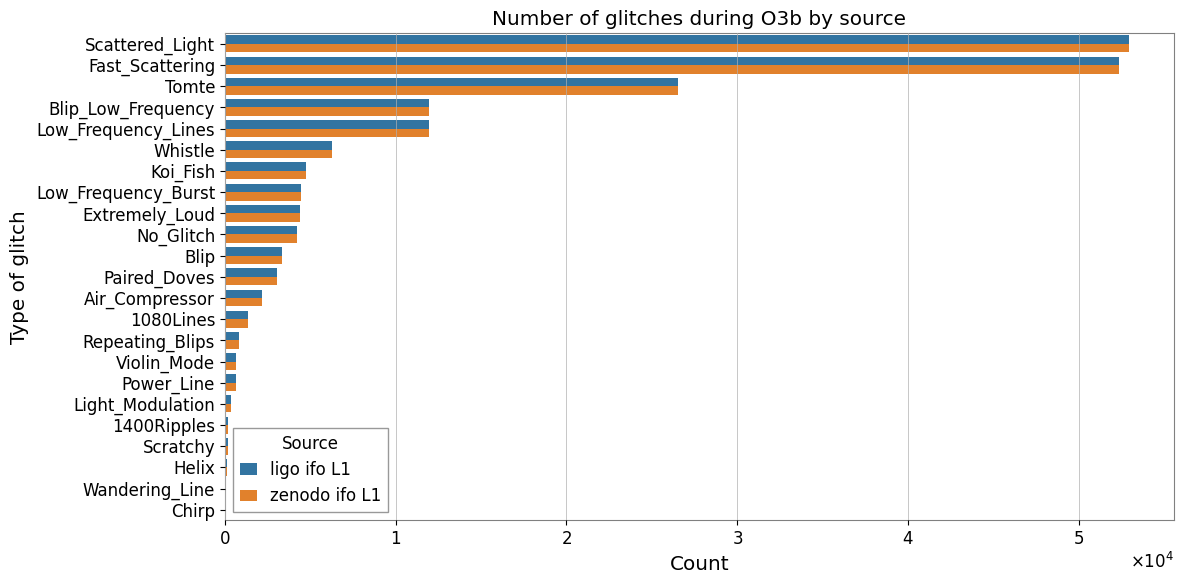

In [86]:
# Adiciona a origem
dfligo_L1_O3b['Fonte'] = 'ligo ifo L1'
dfzenodo_L1_O3b['Fonte'] = 'zenodo ifo L1'

# Junta os dois DataFrames
df_combined = pd.concat([dfligo_L1_O3b, dfzenodo_L1_O3b])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3b by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()


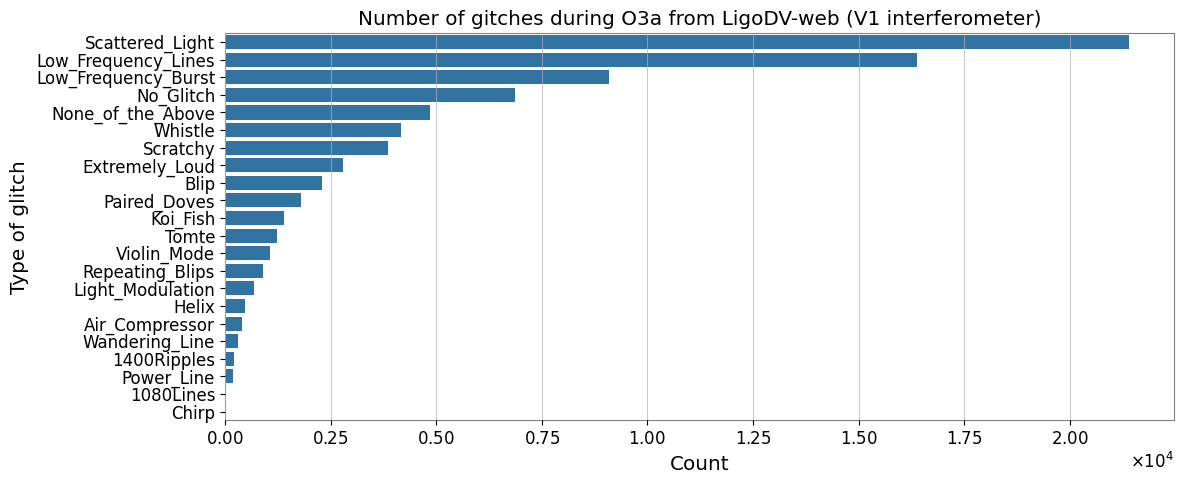

In [88]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfligo_V1_O3a, y='label', order=dfligo_V1_O3a['label'].value_counts().index)
plt.title("Number of gitches during O3a from LigoDV-web (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

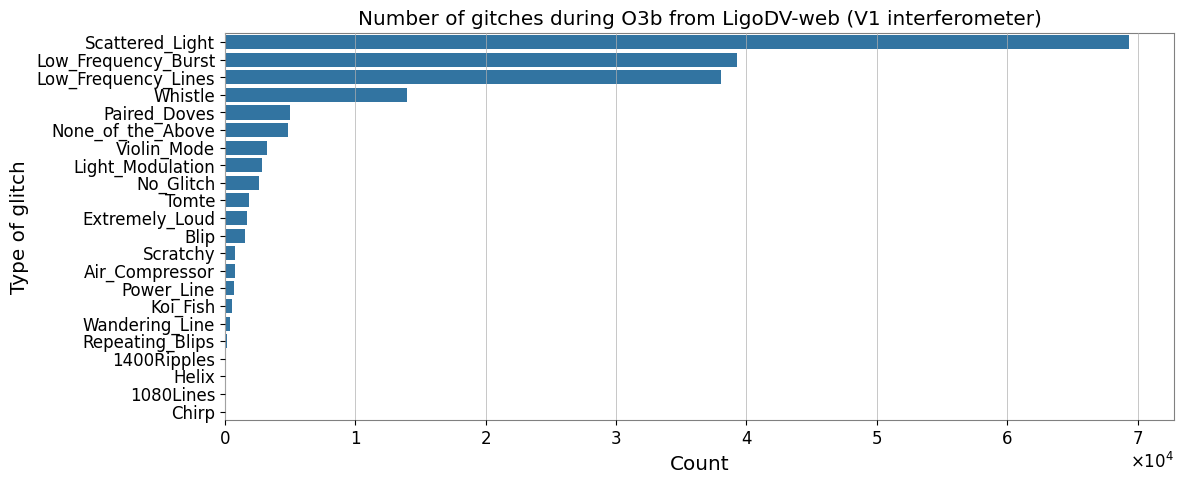

In [91]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfligo_V1_O3b, y='label', order=dfligo_V1_O3b['label'].value_counts().index)
plt.title("Number of gitches during O3b from LigoDV-web (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

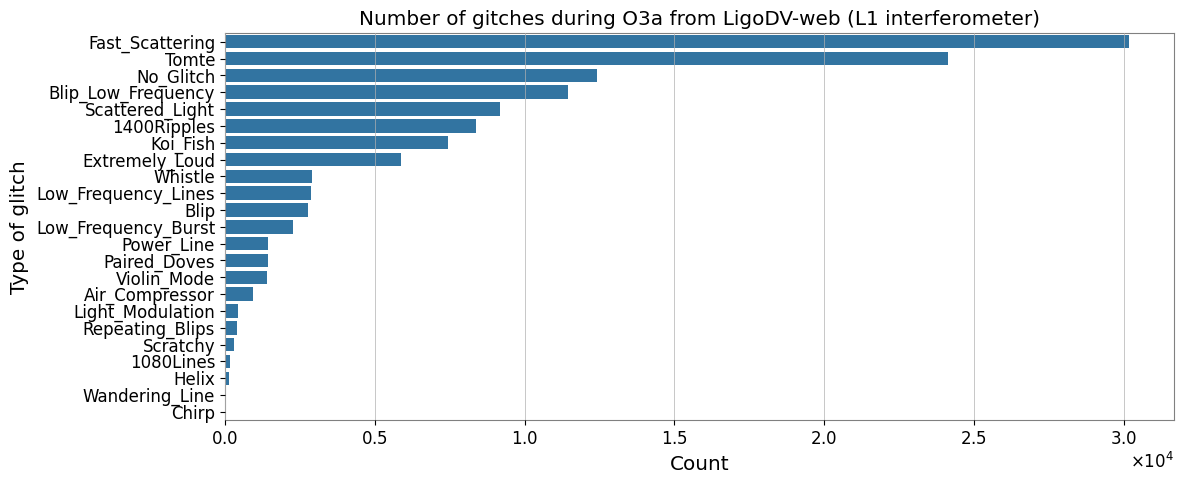

In [51]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfL_O3a, y='label', order=dfL_O3a['label'].value_counts().index)
plt.title("Number of gitches during O3a from LigoDV-web (L1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

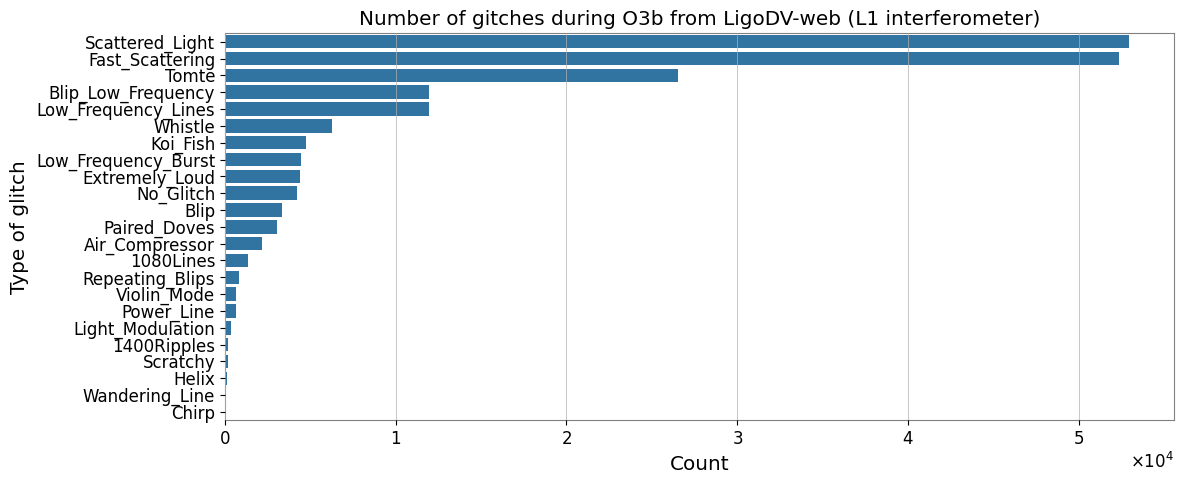

In [52]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfL_O3b, y='label', order=dfL_O3b['label'].value_counts().index)
plt.title("Number of gitches during O3b from LigoDV-web (L1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

## The second one as follow

In [53]:
pip install gwpy gwosc pandas matplotlib seaborn

In [54]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [55]:
# O3a: 1 April 2019 – 1 October 2019
# O3b: 1 November 2019 – 27 March 2020

start = '2019-04-01'
end = '2020-03-27'

transform the import data from LIGO in dataFrame by Pandas libraries and filter possible duplicate data

In [56]:
dfZ_O3a = pd.read_csv("L1_O3a_Zenodo.csv")
dfZ_O3a.drop_duplicates()

dfZ_O3b = pd.read_csv("L1_O3b_Zenodo.csv")
dfZ_O3b.drop_duplicates()

,event_time,ifo,peak_time,peak_time_ns,start_time,start_time_ns,duration,peak_frequency,central_freq,bandwidth,...,Tomte,Violin_Mode,Wandering_Line,Whistle,ml_label,ml_confidence,url1,url2,url3,url4
0,1.257857e+09,L1,1257856978,304687023,1257856978,0,0.54126,30.734230,2651.545166,5257.346680,...,1.113973e-03,2.737003e-04,3.172901e-05,1.084297e-03,Fast_Scattering,0.995725,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
1,1.257853e+09,L1,1257852947,187500000,1257852946,500000000,2.00000,12.025200,12.127810,4.255620,...,2.552599e-05,1.367013e-03,1.903127e-04,3.061646e-03,Low_Frequency_Burst,0.988308,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
2,1.257857e+09,L1,1257856887,595213890,1257856887,0,1.25000,217.740967,2380.014160,4722.197754,...,1.119379e-03,1.088715e-03,1.290115e-04,7.265663e-04,Koi_Fish,0.999981,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
3,1.257850e+09,L1,1257849846,810547113,1257849846,134764909,1.17188,49.208260,3982.888916,7935.187988,...,4.139673e-01,5.565147e-02,2.194980e-03,5.656436e-03,Tomte,1.000000,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
4,1.257850e+09,L1,1257850078,597656011,1257850078,562500000,0.04688,39.789299,53.545750,60.305382,...,7.061602e-02,6.654765e-03,6.159215e-04,3.951192e-03,Blip_Low_Frequency,0.901526,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192688,1.262371e+09,L1,1262370615,937500000,1262370614,750000000,2.00000,30.486750,3981.425049,7938.115723,...,2.690765e-12,2.368561e-09,2.436630e-10,4.375543e-10,Scattered_Light,0.999683,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
192689,1.262374e+09,L1,1262373990,187500000,1262373989,500000000,1.75000,25.965651,768.751953,1506.914307,...,2.067621e-13,1.063041e-07,1.575231e-11,3.597943e-11,Scattered_Light,0.999585,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
192690,1.262372e+09,L1,1262371897,187500000,1262371895,750000000,2.75000,23.330521,3980.906250,7939.152832,...,3.351897e-14,1.191948e-10,1.941215e-12,4.348382e-13,Scattered_Light,0.999962,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
192691,1.262362e+09,L1,1262361507,632812023,1262361507,183593034,0.81641,27.308241,3368.219971,6698.609375,...,3.749429e-07,2.905130e-06,6.172496e-09,1.161038e-07,Fast_Scattering,0.931518,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...


In [57]:
# dfz_O3a['gpstime'] = pd.to_datetime(dfz_O3a['peak_time'], unit='s')
# dfz_O3b['gpstime'] = pd.to_datetime(dfz_O3a['peak_time'], unit='s')

print(dfZ_O3a.columns)

Index(['event_time', 'ifo', 'peak_time', 'peak_time_ns', 'start_time',
       'start_time_ns', 'duration', 'peak_frequency', 'central_freq',
       'bandwidth', 'channel', 'amplitude', 'snr', 'q_value', 'gravityspy_id',
       '1400Ripples', '1080Lines', 'Air_Compressor', 'Blip', 'Chirp',
       'Extremely_Loud', 'Helix', 'Koi_Fish', 'Light_Modulation',
       'Low_Frequency_Burst', 'Low_Frequency_Lines', 'No_Glitch',
       'None_of_the_Above', 'Paired_Doves', 'Power_Line', 'Repeating_Blips',
       'Scattered_Light', 'Scratchy', 'Tomte', 'Violin_Mode', 'Wandering_Line',
       'Whistle', 'ml_label', 'ml_confidence', 'url1', 'url2', 'url3', 'url4'],
      dtype='object')


this data has a lot of intersting columns that we can use, like "event_time", "duration", "ml_confidence" or "peak_time".

we can see the O3a run in dataFrame, for exemple

In [58]:
dfZ_O3a.head()

,event_time,ifo,peak_time,peak_time_ns,start_time,start_time_ns,duration,peak_frequency,central_freq,bandwidth,...,Tomte,Violin_Mode,Wandering_Line,Whistle,ml_label,ml_confidence,url1,url2,url3,url4
0,1.253102e+09,L1,1253102470,687500000,1253102469,250000000,3.00000,19.519409,3981.425049,7938.115723,...,0.000012,0.000018,0.000005,0.001016,Scattered_Light,0.514198,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
1,1.253094e+09,L1,1253093509,929687023,1253093509,812500000,0.18750,27.308241,31.582130,25.333481,...,0.004336,0.001223,0.000011,0.000707,Fast_Scattering,0.710608,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
2,1.253100e+09,L1,1253100460,937500000,1253100459,216797113,7.28320,23.330521,3879.200928,7737.094238,...,0.000008,0.000053,0.000017,0.002770,Scattered_Light,0.966866,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
3,1.253095e+09,L1,1253095251,347656011,1253095251,0,0.50000,39.789299,53.285130,60.826618,...,0.316067,0.064872,0.000545,0.003618,Tomte,0.995652,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
4,1.253068e+09,L1,1253068267,767638921,1253068267,761718034,0.00977,1822.457886,2085.644043,2028.357178,...,0.000007,0.007593,0.000018,0.035755,No_Glitch,0.567025,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...


## Analyze the frequency of each categorized glitch of O3 in general, but also splitting the analysis for O3a (April 1st 2019 - October 1st 2019) and O3b (November 1st 2019 - March 27th 2020) runs;

In [59]:
glitch_types = dfZ_O3a['ml_label'].value_counts()
print(glitch_types)

ml_label
Fast_Scattering        30219
Tomte                  24262
No_Glitch              12688
Blip_Low_Frequency     11473
Scattered_Light         9208
1400Ripples             8340
Koi_Fish                7534
Extremely_Loud          5897
Whistle                 2916
Low_Frequency_Lines     2901
Blip                    2895
Low_Frequency_Burst     2375
Power_Line              1484
Paired_Doves            1442
Violin_Mode             1417
Air_Compressor           931
Light_Modulation         428
Repeating_Blips          414
Scratchy                 312
1080Lines                161
Helix                    142
Wandering_Line            41
Chirp                     10
None_of_the_Above         10
Name: count, dtype: int64


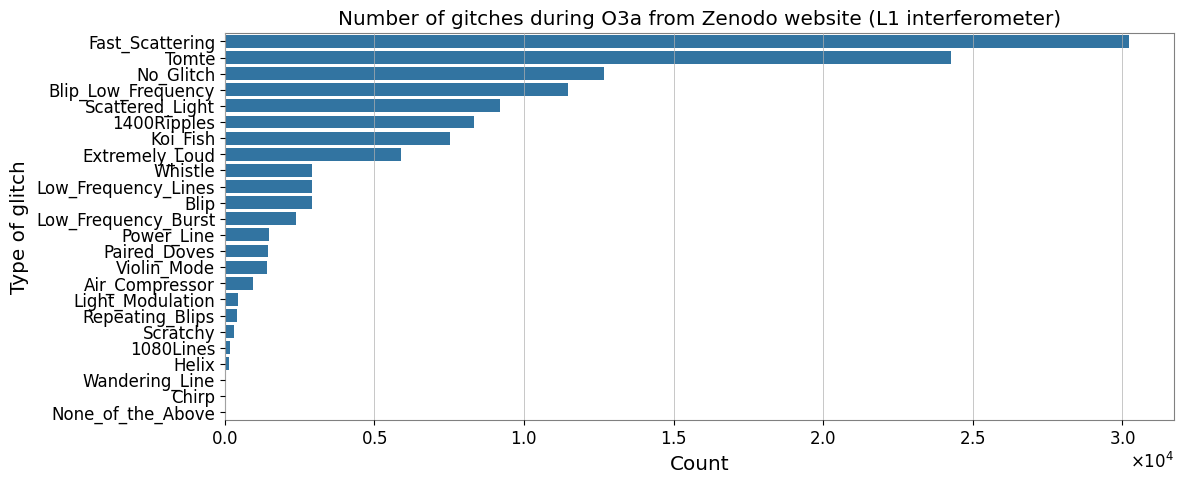

In [60]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfZ_O3a, y='ml_label', order=dfZ_O3a['ml_label'].value_counts().index)
plt.title("Number of gitches during O3a from Zenodo website (L1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

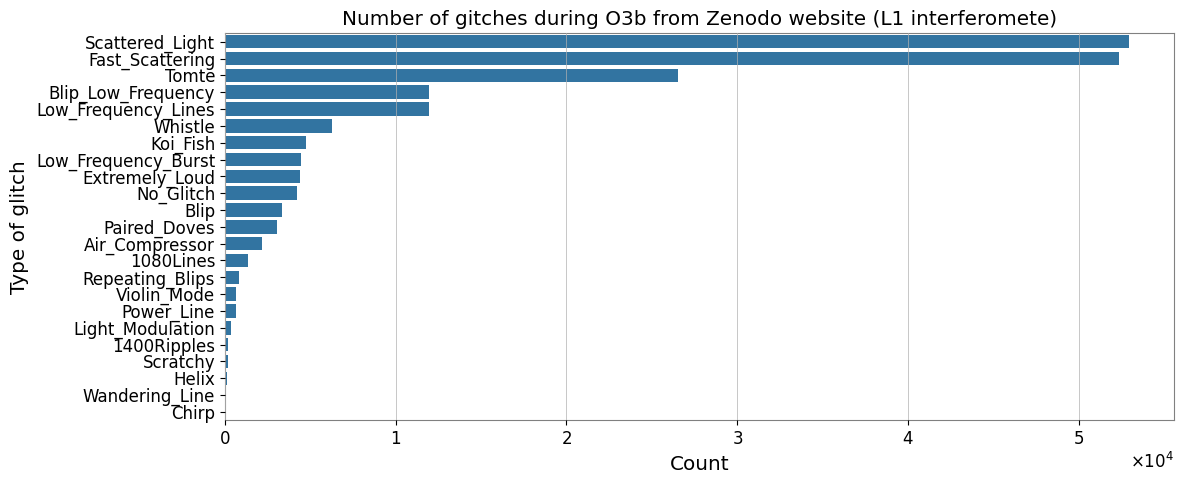

In [61]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfZ_O3b, y='ml_label', order=dfZ_O3b['ml_label'].value_counts().index)
plt.title("Number of gitches during O3b from Zenodo website (L1 interferomete)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

we can see that fast-scattering and scattering-light are the glitches that occurred the most during the O3b run - around November 1st 2019 - March 27th 2020. This agreed with Tabata teses (https://www.gov.br/inpe/pt-br/area-conhecimento/posgraduacao/ast/repositorio-de-arquivos/teses/tese_tabata_aira_ferreira.pdf).

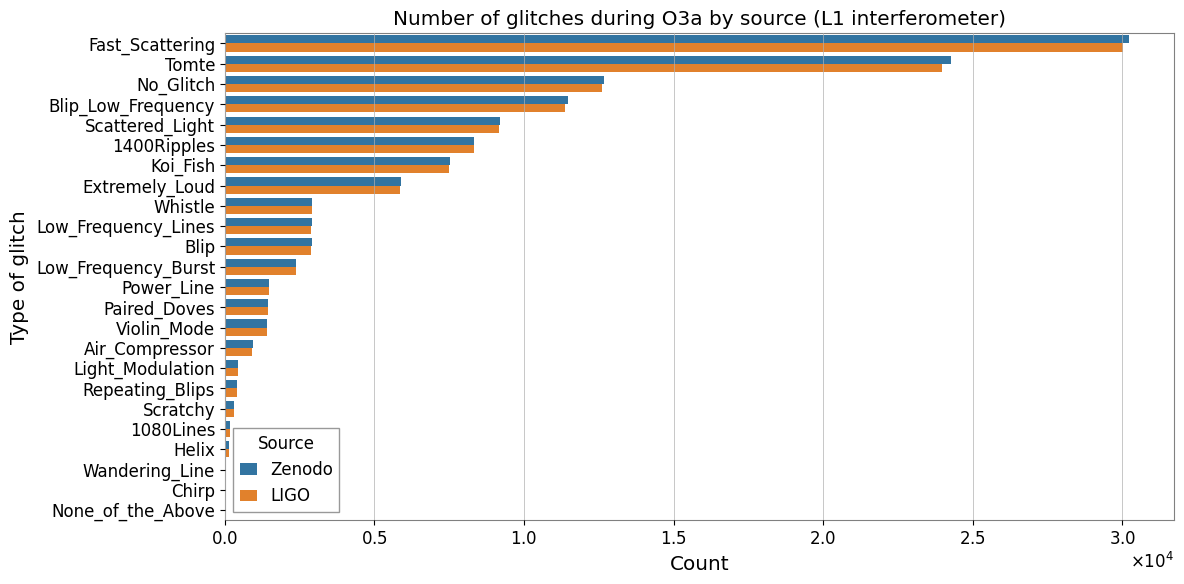

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona a origem
dfZ_O3a['Fonte'] = 'Zenodo'
dfL_O3a['Fonte'] = 'LIGO'

# Junta os dois DataFrames
df_combined = pd.concat([dfZ_O3a, dfL_O3a])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['ml_label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['ml_label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='ml_label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3a by source (L1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()


# Time-tracking of the incidence of each glitch category throughout O3 (monthly, by season, …);

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("gspy.csv")
# df['gpstime'] = pd.to_datetime(df['peak_time'], unit='s')
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'gspy.csv'

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(data=df, y='label')
plt.title("Number of gitches during O3b")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

In [ ]:
# Pegue um glitch do tipo "Blip"
blip = df[df['ml_label'] == 'Blip'].iloc[0]
peak = blip['peak_time']  # tempo em GPS
print("Glitch blip encontrado em:", peak)

# Baixar 2 segundos ao redor do glitch
strain = TimeSeries.fetch_open_data('H1', peak - 1, peak + 1, cache=True)

In [ ]:
# Sinal no tempo
strain.plot()
plt.title("Sinal ao redor do glitch")
plt.show()

# Espectrograma (frequência x tempo)
specgram = strain.spectrogram(fftlength=0.2)
specgram.plot()
plt.title("Espectrograma do glitch")
plt.show()